# DENT detector unisim (Products A + B)

Match at **`sel_all`**, then walk the full event-selection pipeline on matched
files:

1. **Product A** — unisim on **selection / cut-stage** variables  
2. **Product B** — unisim on **measurement** variables at the final (`2prong-mup` / sel_mup) stage  

Default inputs are the **high-stats** campaign:
`DENT-highstats/matched/{cv,dent}/*_matched_hs.df`
(CV = Sep-3 `detvar_CV_updated`, DENT = Sep-9 `detvar_DENT`).

DENT is a pure CV↔variation unisim (like cosmics).

Outputs (under `systematics-final/DENT-highstats/`):
- `DetectorSelection/detector_sel_syst_dict.npz` (A)
- `Detector/detector_syst_dict.npz` (B)

Hist cache: prefers `cache/dent_sel_all_products.pkl`; if missing, migrates
`dent_sel_all_hists.pkl` from the prior `dent_compare` walk. Set
`DENT_FORCE_REPROCESS=1` to rewalk matched files.


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO = Path("/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana")
sys.path.insert(0, str(REPO))

from analysis_village.numucc_1p0pi.dataset_locations import PLOTS_BASE, SPRING_GEN1_ROOT
from analysis_village.numucc_1p0pi.scripts import dent_compare as dc
from analysis_village.numucc_1p0pi.syst_disk_layout import (
    FILE_DETECTOR,
    FILE_DETECTOR_SEL,
    SUB_DETECTOR,
    SUB_DETECTOR_SEL,
)
from analysis_village.numucc_1p0pi.syst_detvar_common import (
    accumulate_matched_sel_all_cv_vs_var_products,
    assert_variations_matched,
    build_dent_detector_dict,
    frac_unc_pct_from_pack,
    glob_matched_dfs,
    load_or_build_cache,
    log,
    pot_scales_to_cv,
    save_detector_npz,
)
from analysis_village.numucc_1p0pi.utils import dpi
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig


In [3]:
DFS = Path(os.environ.get("NUMUCC_SPRING_GEN1_ROOT", SPRING_GEN1_ROOT))

# High-stats matched products (preferred). Written with --matched-suffix _matched_hs.
_HS_ROOT = Path(PLOTS_BASE) / "systematics-final" / "DENT-highstats"
_HS_MATCHED = {
    "CV": _HS_ROOT / "matched" / "cv",
    "DENT": _HS_ROOT / "matched" / "dent",
}

# Raw sel_all campaigns (used only if high-stats matched dirs are missing).
_RAW = {
    "CV": DFS / "2026_09_03_032325__sel_all-mc-BNB_cosmics-detvar_CV_updated",
    "DENT": DFS / "2026_09_09_230442__sel_all-mc-BNB_cosmics-detvar_DENT",
}
# Older Sep-3 DENT_updated pair (fallback).
_RAW_OLD = {
    "CV": DFS / "2026_09_03_032325__sel_all-mc-BNB_cosmics-detvar_CV_updated",
    "DENT": DFS / "2026_09_03_032705__sel_all-mc-BNB_cosmics-detvar_DENT_updated",
}

if all(p.is_dir() and any(p.glob("*_matched_hs.df")) for p in _HS_MATCHED.values()):
    DENT_DIRS = _HS_MATCHED
    MATCHED_SUFFIX = "_matched_hs"
    OUT_BASE = Path(os.environ.get("DENT_OUT_BASE", str(_HS_ROOT)))
    print("using high-stats matched dirs (_matched_hs)")
elif all(p.is_dir() for p in _RAW.values()):
    DENT_DIRS = _RAW
    MATCHED_SUFFIX = "_matched_hs"
    OUT_BASE = Path(os.environ.get("DENT_OUT_BASE", str(_HS_ROOT)))
    print("using raw high-stats campaigns — run matching first if no *_matched_hs.df")
elif all(p.is_dir() for p in _RAW_OLD.values()):
    DENT_DIRS = _RAW_OLD
    MATCHED_SUFFIX = "_matched"
    OUT_BASE = Path(os.environ.get("DENT_OUT_BASE", str(PLOTS_BASE / "systematics-final" / "DENT")))
    print("using Sep-3 DENT_updated (_matched)")
else:
    DENT_DIRS = {
        "CV": DFS / "2026_08_19_031254__sel_all-mc-CV",
        "DENT": DFS / "2026_08_18_120607__sel_all-mc-DENT",
    }
    MATCHED_SUFFIX = "_matched"
    OUT_BASE = Path(os.environ.get("DENT_OUT_BASE", str(PLOTS_BASE / "systematics-final" / "DENT")))
    print("using legacy Aug DENT dirs")

CACHE_DIR = OUT_BASE / "cache"
FIG_DIR = OUT_BASE / "plots"
DET_B_DIR = OUT_BASE / SUB_DETECTOR
DET_A_DIR = OUT_BASE / SUB_DETECTOR_SEL
CACHE_PATH = CACHE_DIR / "dent_sel_all_products.pkl"
NPZ_B = DET_B_DIR / FILE_DETECTOR
NPZ_A = DET_A_DIR / FILE_DETECTOR_SEL

FORCE_REPROCESS = os.environ.get("DENT_FORCE_REPROCESS", "0") == "1"
ASSERT_MAX_FILES = int(os.environ.get("DENT_ASSERT_MAX_FILES", "20"))
SAVE_FIGS = True

for d in (CACHE_DIR, FIG_DIR, DET_A_DIR, DET_B_DIR):
    d.mkdir(parents=True, exist_ok=True)

VARIATIONS = {
    lab: glob_matched_dfs(p, filename_str="sel_all", matched_suffix=MATCHED_SUFFIX)
    for lab, p in DENT_DIRS.items()
}
for lab, files in VARIATIONS.items():
    print(f"{lab}: {len(files)} matched sel_all files  ({DENT_DIRS[lab]})")
print("matched_suffix:", MATCHED_SUFFIX)
print("cache:", CACHE_PATH)
print("Product A:", NPZ_A)
print("Product B:", NPZ_B)


using high-stats matched dirs (_matched_hs)
CV: 3000 matched sel_all files  (/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/DENT-highstats/matched/cv)
DENT: 1997 matched sel_all files  (/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/DENT-highstats/matched/dent)
matched_suffix: _matched_hs
cache: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/DENT-highstats/cache/dent_sel_all_products.pkl
Product A: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/DENT-highstats/DetectorSelection/detector_sel_syst_dict.npz
Product B: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/DENT-highstats/Detector/detector_syst_dict.npz


In [4]:
COMMON_KEYS_PKL = OUT_BASE / "cache" / "dent_common_keys_sel_all.pkl"

assert_variations_matched(
    {k: v for k, v in VARIATIONS.items() if v},
    max_files_per_var=ASSERT_MAX_FILES,
    format="sel_all",
    common_keys_path=COMMON_KEYS_PKL if COMMON_KEYS_PKL.is_file() else None,
)


[13:42:45] loaded common keys (1,963,782) from /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/DENT-highstats/cache/dent_common_keys_sel_all.pkl


sel_all meta scan: 100%|██████████| 20/20 [00:15<00:00,  1.26it/s]

[13:43:00]   CV: 3000 files, scan 20 → 13,563 event keys



sel_all meta scan: 100%|██████████| 20/20 [00:12<00:00,  1.61it/s]

[13:43:13]   DENT: 1997 files, scan 20 → 19,790 event keys
[13:43:13] assert OK: 2 variations ⊆ common keys (1,963,782)


{(2.948246955871582, 733, 32, 26),
 (1.1556528806686401, 633, 72, 20),
 (0.8856528997421265, 22626, 30, 14),
 (0.708193302154541, 22021, 58, 36),
 (1.579200267791748, 22969, 8, 24),
 (0.6002873182296753, 388, 53, 10),
 (2.661339521408081, 669, 57, 47),
 (0.7504584789276123, 220, 2, 38),
 (0.5248612761497498, 149, 60, 19),
 (2.6119301319122314, 55, 60, 46),
 (2.276444911956787, 22645, 89, 20),
 (0.8299237489700317, 1150, 60, 36),
 (1.2703222036361694, 66, 70, 17),
 (0.7643488049507141, 135, 40, 6),
 (1.5952975749969482, 435, 7, 21),
 (1.6985667943954468, 1159, 87, 33),
 (1.270376205444336, 23954, 94, 49),
 (0.7555596828460693, 244, 98, 2),
 (0.8991906642913818, 151, 95, 30),
 (0.39604368805885315, 1466, 37, 4),
 (1.2901414632797241, 22631, 58, 22),
 (1.424271821975708, 22768, 73, 46),
 (3.468425750732422, 22627, 54, 40),
 (2.0023927688598633, 20854, 49, 34),
 (1.3653768301010132, 22611, 23, 22),
 (1.200051188468933, 1521, 10, 21),
 (0.8101020455360413, 72, 65, 31),
 (1.4692513942718506,

In [5]:
FINAL_VAR_DEFS = dc.build_final_var_defs()
CUT_VAR_DEFS = dc.build_sel_all_var_defs()
print(f"cut-stage vars: {len(CUT_VAR_DEFS)}  final vars: {len(FINAL_VAR_DEFS)}")


def _migrate_dent_compare_hists(hists_path: Path) -> dict:
    """Convert legacy dent_compare ``dent_sel_all_hists.pkl`` → products payload."""
    import pickle as _pickle
    import sys as _sys

    from analysis_village.numucc_1p0pi.scripts import dent_compare as _dc

    # Pickles may reference ``__main__.StageMetrics`` from the CLI run.
    _main = _sys.modules["__main__"]
    _main.StageMetrics = _dc.StageMetrics
    _main.SampleSummary = _dc.SampleSummary
    with open(hists_path, "rb") as fh:
        old = _pickle.load(fh)
    cut_names = list(old["cut_var_names"])
    final_names = list(old["final_var_names"])

    def _split(lab: str) -> dict:
        h = old["hists"][lab]
        return {
            "hists_cut": {k: np.asarray(h[k], dtype=float) for k in cut_names},
            "hists_final": {k: np.asarray(h[k], dtype=float) for k in final_names},
            "pot": float(old["pots"][lab]),
        }

    products = {"cv": _split("cv"), "var": _split("dent")}
    pot_by = {"CV": products["cv"]["pot"], "DENT": products["var"]["pot"]}
    scales = pot_scales_to_cv(pot_by, reference="CV")
    sc = float(scales.get("DENT", 1.0))
    if abs(sc - 1.0) > 1e-15:
        for key in ("hists_cut", "hists_final"):
            products["var"][key] = {
                k: np.asarray(v, dtype=float) * sc for k, v in products["var"][key].items()
            }
    log(f"migrated products cache from {hists_path}")
    return {
        "products": products,
        "pot_by_variation": pot_by,
        "pot_scales": scales,
        "match_stage": "sel_all",
        "variations": {k: list(v) for k, v in VARIATIONS.items()},
        "converted_from": str(hists_path),
    }


def _build_dent_cache():
    legacy = CACHE_DIR / "dent_sel_all_hists.pkl"
    if legacy.is_file() and not FORCE_REPROCESS:
        return _migrate_dent_compare_hists(legacy)
    files_cv, files_dent = VARIATIONS["CV"], VARIATIONS["DENT"]
    if not files_cv or not files_dent:
        raise RuntimeError("no matched sel_all files — run systematics-detector-match.ipynb first")
    log(f"walk matched sel_all (cut+final): CV={len(files_cv)} DENT={len(files_dent)}")
    products = accumulate_matched_sel_all_cv_vs_var_products(
        files_cv,
        files_dent,
        final_var_defs=FINAL_VAR_DEFS,
        include_cut_stage=True,
    )
    pot_by = {"CV": products["cv"]["pot"], "DENT": products["var"]["pot"]}
    scales = pot_scales_to_cv(pot_by, reference="CV")
    sc = float(scales.get("DENT", 1.0))
    if abs(sc - 1.0) > 1e-15:
        for key in ("hists_cut", "hists_final"):
            products["var"][key] = {
                k: np.asarray(v, dtype=float) * sc for k, v in products["var"][key].items()
            }
    return {
        "products": products,
        "pot_by_variation": pot_by,
        "pot_scales": scales,
        "match_stage": "sel_all",
        "variations": {k: list(v) for k, v in VARIATIONS.items()},
    }


payload = load_or_build_cache(CACHE_PATH, _build_dent_cache, force=FORCE_REPROCESS)
products = payload["products"]
print("POT scales:", payload.get("pot_scales"))
print("n cut vars:", len(products["cv"]["hists_cut"]))
print("n final vars:", len(products["cv"]["hists_final"]))


cut-stage vars: 30  final vars: 24
[13:43:13] loaded hist cache ← /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/DENT-highstats/cache/dent_sel_all_products.pkl
POT scales: {'CV': 1.0, 'DENT': 0.9999999983578473}
n cut vars: 30
n final vars: 24


In [6]:
# Product A — selection / cut-stage
h_cv_cut = products["cv"]["hists_cut"]
h_dent_cut = products["var"]["hists_cut"]
dict_a = build_dent_detector_dict(h_cv_cut, h_dent_cut, list(h_cv_cut.keys()))
save_detector_npz(
    dict_a,
    NPZ_A,
    manifest={
        "source": "DENT",
        "product": "A_selection",
        "match_stage": "sel_all",
        "cache": str(CACHE_PATH),
        "n_vars": len(dict_a.get("detector-DENT", {})),
    },
)

# Product B — measurement / final
h_cv_f = products["cv"]["hists_final"]
h_dent_f = products["var"]["hists_final"]
dict_b = build_dent_detector_dict(h_cv_f, h_dent_f, list(h_cv_f.keys()))
save_detector_npz(
    dict_b,
    NPZ_B,
    manifest={
        "source": "DENT",
        "product": "B_measurement",
        "match_stage": "sel_all",
        "cache": str(CACHE_PATH),
        "n_vars": len(dict_b.get("detector-DENT", {})),
    },
)
print("Product A vars:", len(dict_a.get("detector-DENT", {})))
print("Product B vars:", len(dict_b.get("detector-DENT", {})))


[13:43:14] wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/DENT-highstats/DetectorSelection/detector_sel_syst_dict.npz
[13:43:14] wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/DENT-highstats/DetectorSelection/detector_sel_syst_dict_manifest.json
[13:43:14] wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/DENT-highstats/Detector/detector_syst_dict.npz
[13:43:14] wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/DENT-highstats/detector_covariance_manifest.json
Product A vars: 30
Product B vars: 24


## Quick inspect (Product B)


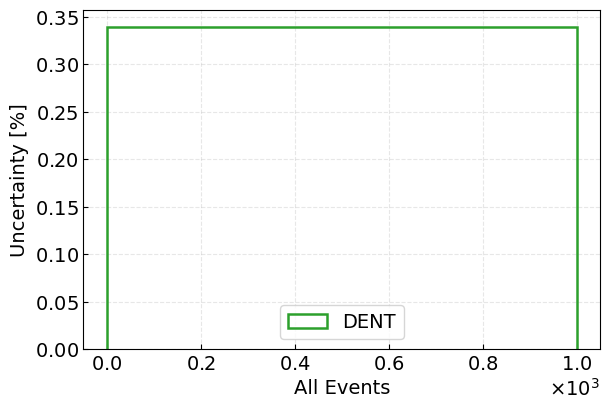

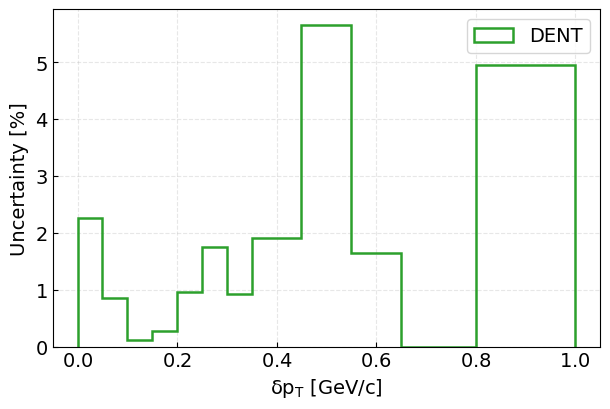

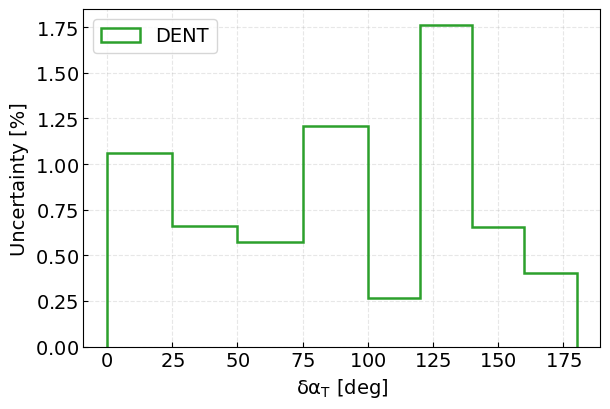

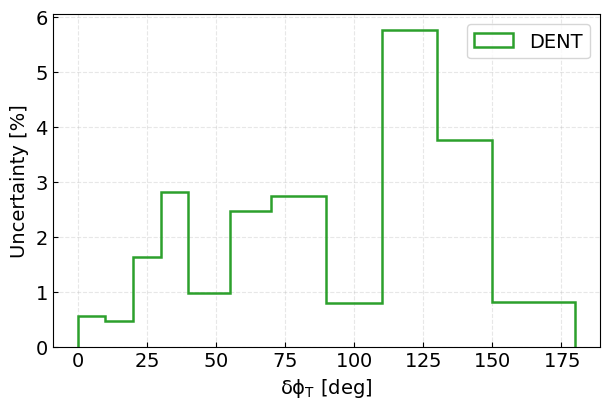

In [7]:
for vc in (VariableConfig.all_events(), VariableConfig.tki_del_Tp(), VariableConfig.tki_del_alpha(), VariableConfig.tki_del_phi()):
    vsn = vc.var_save_name
    pack = dict_b.get("detector-DENT", {}).get(vsn)
    if pack is None:
        print("missing", vsn)
        continue
    fig, ax = plt.subplots(figsize=(6.2, 4.2))
    w = frac_unc_pct_from_pack(pack)
    ax.hist(vc.bin_centers, bins=vc.bins, weights=w, histtype="step", lw=1.8, color="C2", label="DENT")
    ax.set_ylabel("Uncertainty [%]")
    ax.set_xlabel(vc.var_labels[0] if vc.var_labels else vsn)
    ax.set_ylim(bottom=0)
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if SAVE_FIGS:
        fig.savefig(FIG_DIR / f"dent_frac_unc__{vsn}.png", dpi=dpi, bbox_inches="tight")
    plt.show()


## Exploring uncertainty smoothing (Product B)

Final-stage DENT unisim uncertainties are noisy: each bin’s fractional unc is
built from a single CV↔DENT difference, so empty / low-count bins jump around.

This section only **compares** smoothers on the fractional uncertainty
\(\sigma_i / N_i^{\mathrm{CV}}\) — it does **not** overwrite the saved NPZs.

**Approaches worth trying (common for HEP unisims):**

1. **Moving average / Gaussian kernel on \(\sigma/N\)** — simplest; kills bin-to-bin
   jitter. Tune window / \(\sigma\) in bin units.
2. **Savitzky–Golay** — local polynomial; keeps broad shape better than a boxcar.
3. **ROOT `TH1::Smooth` / Friedman 353QH twice** — classic HEP smoother (HBOOK
   `hsmoof.F`, what `TH1::Smooth()` calls). Nonlinear: running medians 3–5–3,
   quadratic fill of flat stretches, Hanning mean, then the same on residuals
   and add back. Good at killing spikes while preserving edges better than a
   Gaussian. See Friedman, SLAC-R-176 §4.2 / 1974 CERN School.
4. **Smooth signed relative shift, then abs** — smooth
   \((N^{\mathrm{DENT}}-N^{\mathrm{CV}})/N^{\mathrm{CV}}\) first (signed), then take
   \(|\cdot|\). Avoids rectification bias from smoothing already-positive noise.
5. **Smooth templates, then recompute unisim** — Gaussian-smooth CV and DENT
   counts (same kernel), then rebuild \(\lvert\Delta\rvert/N\). Closer to “the
   detector effect is smooth in observable space.”
6. **Shrink / floor toward a constant** — e.g. replace wild bins with
   \(\max(\sigma_i,\,u_{\mathrm{floor}})\) or shrink toward the median / POT-scale
   integrated unc (similar spirit to cosmics blow-up → flat).
7. **Coarser rebin for the systematic only** — evaluate DENT on fewer bins, then
   interpolate back (or assign a piecewise-constant unc). Strong when the true
   effect is nearly flat.

Usually start with **(3)** or **(4)/(5)** at modest strength; use (6)/(7) if tails
stay wild. Also watch: over-smoothing can hide real shape (e.g. edges of acceptance).


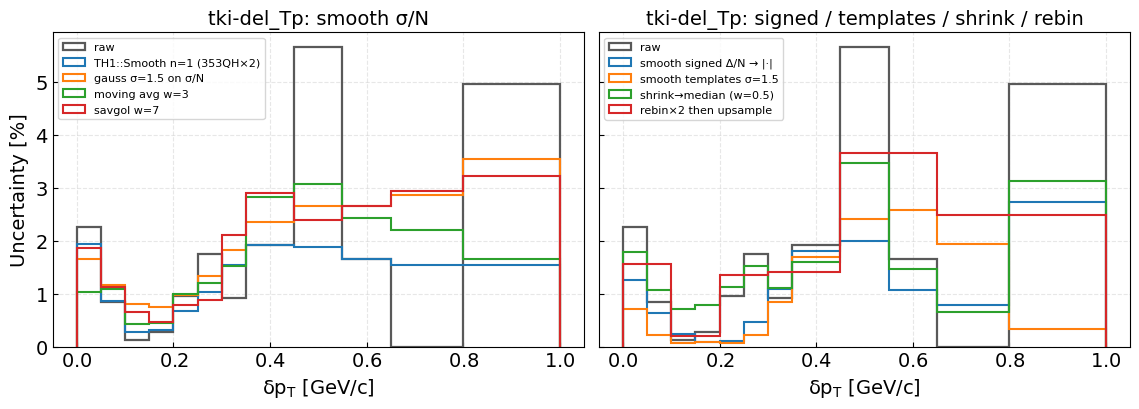

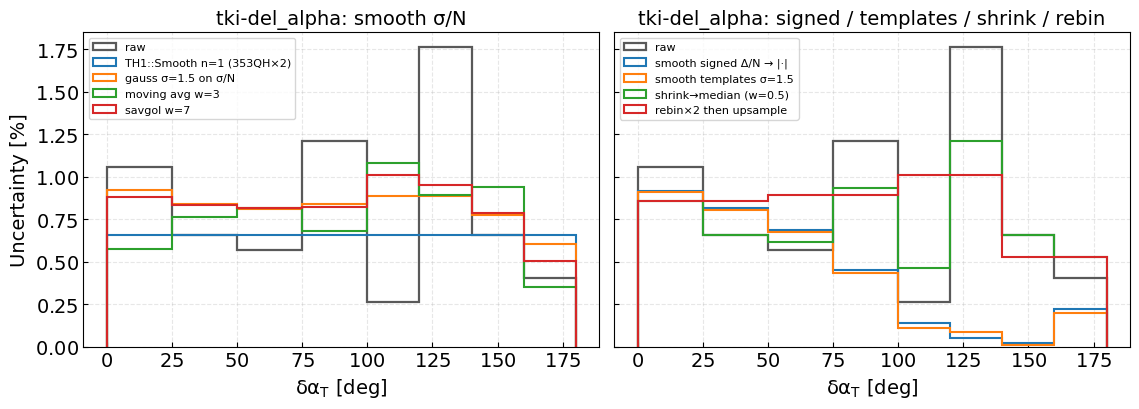

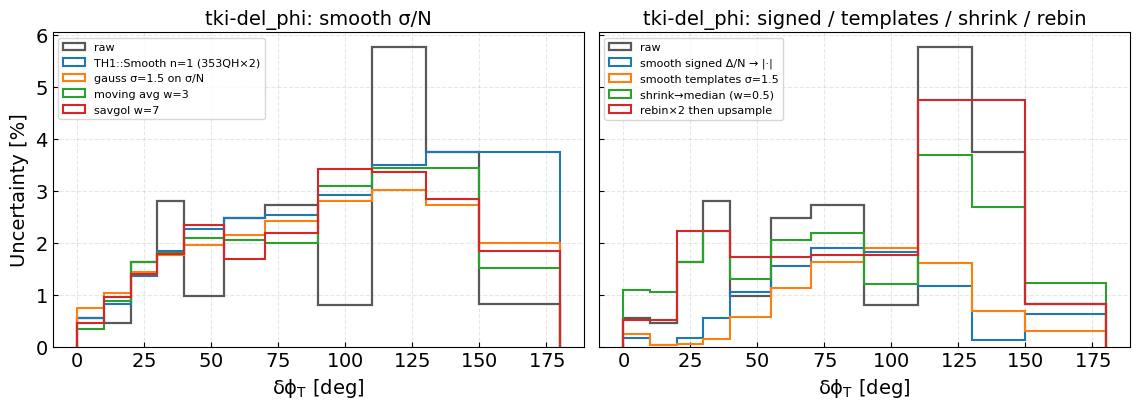

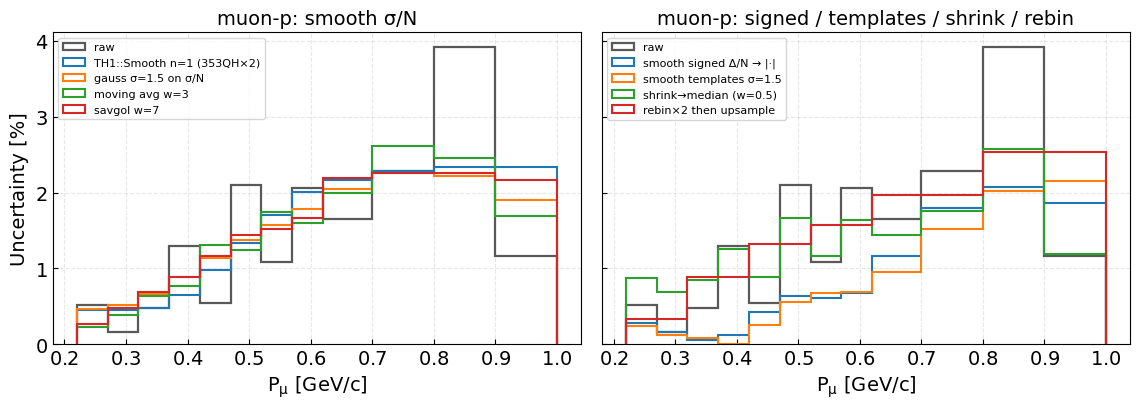

summary (noise proxy ≈ std of bin % unc):
  tki-del_Tp          raw                                       mean=  1.78  med=  1.30  max=  5.65  std=  1.73
  tki-del_Tp          TH1::Smooth n=1 (353QH×2)                 mean=  1.26  med=  1.53  max=  1.94  std=  0.59
  tki-del_Tp          gauss σ=1.5 on σ/N                        mean=  1.88  med=  1.73  max=  3.53  std=  0.88
  tki-del_Tp          moving avg w=3                            mean=  1.57  med=  1.37  max=  3.07  std=  0.84
  tki-del_Tp          savgol w=7                                mean=  1.83  med=  1.98  max=  3.22  std=  0.96
  tki-del_Tp          smooth signed Δ/N → |·|                   mean=  1.02  med=  0.93  max=  2.74  std=  0.79
  tki-del_Tp          smooth templates σ=1.5                    mean=  0.93  med=  0.52  max=  2.58  std=  0.92
  tki-del_Tp          shrink→median (w=0.5)                     mean=  1.54  med=  1.30  max=  3.48  std=  0.86
  tki-del_Tp          rebin×2 then upsample                   

In [10]:
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter

SMOOTH_FIG_DIR = FIG_DIR / "smoothing"
SMOOTH_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Tunables (bin units). Keep modest — goal is to kill MC-stat jitter, not flatten shape.
GAUSS_SIGMA_BINS = 1.5
MOVING_AVG_WIDTH = 3  # odd
SAVGOL_WINDOW = 7  # odd
SAVGOL_POLY = 2
TEMPLATE_GAUSS_SIGMA = 1.5
SHRINK_TO_MEDIAN_WEIGHT = 0.5  # 0 = raw, 1 = flat median
TH1_SMOOTH_NTIMES = 1  # ROOT TH1::Smooth(ntimes) default


def _odd(n: int) -> int:
    n = max(3, int(n))
    return n if n % 2 else n + 1


def _nan_safe_smooth(y: np.ndarray, smoother) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    out = np.full_like(y, np.nan, dtype=float)
    m = np.isfinite(y)
    if m.sum() < 3:
        return out
    # interpolate gaps so 1-D filters see a continuous curve, then mask back
    x = np.arange(len(y), dtype=float)
    y_fill = np.interp(x, x[m], y[m])
    out[:] = smoother(y_fill)
    out[~m] = np.nan
    return out


def frac_from_hists(n_cv: np.ndarray, n_var: np.ndarray, *, eps: float = 1e-12) -> np.ndarray:
    """Raw unisim fractional unc (absolute relative shift)."""
    n_cv = np.asarray(n_cv, dtype=float)
    n_var = np.asarray(n_var, dtype=float)
    return np.abs(n_var - n_cv) / np.maximum(n_cv, eps)


def signed_rel(n_cv: np.ndarray, n_var: np.ndarray, *, eps: float = 1e-12) -> np.ndarray:
    n_cv = np.asarray(n_cv, dtype=float)
    n_var = np.asarray(n_var, dtype=float)
    return (n_var - n_cv) / np.maximum(n_cv, eps)


def smooth_moving_avg(y: np.ndarray, width: int = MOVING_AVG_WIDTH) -> np.ndarray:
    w = _odd(width)
    kernel = np.ones(w, dtype=float) / w

    def _fn(yf):
        return np.convolve(yf, kernel, mode="same")

    return _nan_safe_smooth(y, _fn)


def smooth_gauss(y: np.ndarray, sigma: float = GAUSS_SIGMA_BINS) -> np.ndarray:
    return _nan_safe_smooth(y, lambda yf: gaussian_filter1d(yf, sigma=float(sigma), mode="nearest"))


def smooth_savgol(
    y: np.ndarray, window: int = SAVGOL_WINDOW, poly: int = SAVGOL_POLY
) -> np.ndarray:
    w = _odd(window)
    if len(y) < w:
        return smooth_gauss(y)

    def _fn(yf):
        wl = min(w, len(yf))
        if wl % 2 == 0:
            wl -= 1
        if wl < 3:
            return yf
        return savgol_filter(yf, window_length=wl, polyorder=min(poly, wl - 1))

    return _nan_safe_smooth(y, _fn)


def _median_n(vals: np.ndarray) -> float:
    return float(np.median(np.asarray(vals, dtype=float)))


def smooth_array_353qh(xx: np.ndarray, ntimes: int = 1) -> np.ndarray:
    """ROOT ``TH1::SmoothArray`` — Friedman 353QH applied twice per pass.

    Port of ``hist/hist/src/TH1.cxx`` (HBOOK ``hsmoof.F``):
      * 353 — running medians of width 3, then 5, then 3
      * Q   — quadratic interpolation on flat 3-bin plateaus
      * H   — Hanning running mean (0.25, 0.5, 0.25)
      * twice — repeat on residuals and add back (Tukey)

    If the input minimum is ≥ 0 (e.g. fractional unc), negatives are clipped to 0
    as in ROOT.
    """
    xx = np.asarray(xx, dtype=float).copy()
    nn = int(xx.size)
    if nn < 3:
        return xx
    ntimes = max(1, int(ntimes))

    yy = np.empty(nn, dtype=float)
    zz = np.empty(nn, dtype=float)
    rr = np.empty(nn, dtype=float)

    for _pass in range(ntimes):
        zz[:] = xx
        for noent in range(2):  # algorithm twice: data, then residuals
            for kk in range(3):  # medians 3, 5, 3
                yy[:] = zz
                median_type = 3 if kk != 1 else 5
                ifirst = 1 if kk != 1 else 2
                ilast = nn - 1 if kk != 1 else nn - 2
                for ii in range(ifirst, ilast):
                    # window starts at ii - ifirst (ROOT: yy.data() + ii - ifirst)
                    zz[ii] = _median_n(yy[ii - ifirst : ii - ifirst + median_type])

                if kk == 0:  # first median 3 — special endpoints
                    hh = np.array([zz[1], zz[0], 3 * zz[1] - 2 * zz[2]], dtype=float)
                    zz[0] = _median_n(hh)
                    hh = np.array(
                        [zz[nn - 2], zz[nn - 1], 3 * zz[nn - 2] - 2 * zz[nn - 3]],
                        dtype=float,
                    )
                    zz[nn - 1] = _median_n(hh)

                if kk == 1:  # median 5 — near-edge width-3
                    zz[1] = _median_n(yy[0:3])
                    zz[nn - 2] = _median_n(yy[nn - 3 : nn])

            yy[:] = zz

            # quadratic interpolation for flat segments
            for ii in range(2, nn - 2):
                if zz[ii - 1] != zz[ii] or zz[ii] != zz[ii + 1]:
                    continue
                tmp0 = zz[ii - 2] - zz[ii]
                tmp1 = zz[ii + 2] - zz[ii]
                if tmp0 * tmp1 <= 0:
                    continue
                jk = 1 if abs(tmp1) <= abs(tmp0) else -1
                yy[ii] = -0.5 * zz[ii - 2 * jk] + zz[ii] / 0.75 + zz[ii + 2 * jk] / 6.0
                yy[ii + jk] = 0.5 * (zz[ii + 2 * jk] - zz[ii - 2 * jk]) + zz[ii]

            # Hanning running means
            for ii in range(1, nn - 1):
                zz[ii] = 0.25 * yy[ii - 1] + 0.5 * yy[ii] + 0.25 * yy[ii + 1]
            zz[0] = yy[0]
            zz[nn - 1] = yy[nn - 1]

            if noent == 0:
                rr[:] = zz
                zz[:] = xx - zz  # residuals for second pass

        xmin = float(np.min(xx))
        if xmin < 0:
            xx[:] = rr + zz
        else:
            xx[:] = np.maximum(rr + zz, 0.0)
    return xx


def smooth_th1(y: np.ndarray, ntimes: int = TH1_SMOOTH_NTIMES) -> np.ndarray:
    """Nan-safe wrapper around Friedman 353QH (ROOT ``TH1::Smooth``)."""
    return _nan_safe_smooth(y, lambda yf: smooth_array_353qh(yf, ntimes=ntimes))


def smooth_signed_then_abs(n_cv, n_var, smoother=smooth_gauss) -> np.ndarray:
    return np.abs(smoother(signed_rel(n_cv, n_var)))


def smooth_templates_then_unisim(n_cv, n_var, sigma: float = TEMPLATE_GAUSS_SIGMA) -> np.ndarray:
    n_cv_s = gaussian_filter1d(np.asarray(n_cv, dtype=float), sigma=float(sigma), mode="nearest")
    n_var_s = gaussian_filter1d(np.asarray(n_var, dtype=float), sigma=float(sigma), mode="nearest")
    return frac_from_hists(n_cv_s, n_var_s)


def shrink_to_median(frac: np.ndarray, weight: float = SHRINK_TO_MEDIAN_WEIGHT) -> np.ndarray:
    f = np.asarray(frac, dtype=float)
    med = np.nanmedian(f)
    w = float(np.clip(weight, 0.0, 1.0))
    return (1.0 - w) * f + w * med


def rebin_frac_unc_then_upsample(frac: np.ndarray, factor: int = 2) -> np.ndarray:
    """Average frac unc in blocks of ``factor`` bins, then expand piecewise-constant."""
    f = np.asarray(frac, dtype=float)
    n = len(f)
    fac = max(1, int(factor))
    n_pad = int(np.ceil(n / fac) * fac)
    pad = np.full(n_pad, np.nan, dtype=float)
    pad[:n] = f
    blocks = pad.reshape(-1, fac)
    with np.errstate(all="ignore"):
        means = np.nanmean(blocks, axis=1)
    up = np.repeat(means, fac)[:n]
    return up


SMOOTH_VARS = [
    VariableConfig.tki_del_Tp(),
    VariableConfig.tki_del_alpha(),
    VariableConfig.tki_del_phi(),
    VariableConfig.muon_momentum(),
]

rows = []
for vc in SMOOTH_VARS:
    vsn = vc.var_save_name
    if vsn not in h_cv_f or vsn not in h_dent_f:
        print("skip (no hist)", vsn)
        continue
    n_cv = np.asarray(h_cv_f[vsn], dtype=float)
    n_dent = np.asarray(h_dent_f[vsn], dtype=float)
    raw = 100.0 * frac_from_hists(n_cv, n_dent)
    # Prefer pack diag when present (matches saved Product B)
    pack = dict_b.get("detector-DENT", {}).get(vsn)
    if pack is not None:
        raw = frac_unc_pct_from_pack(pack)

    curves = {
        "raw": raw,
        f"TH1::Smooth n={TH1_SMOOTH_NTIMES} (353QH×2)": 100.0 * smooth_th1(raw / 100.0),
        f"gauss σ={GAUSS_SIGMA_BINS} on σ/N": 100.0 * smooth_gauss(raw / 100.0),
        f"moving avg w={_odd(MOVING_AVG_WIDTH)}": 100.0 * smooth_moving_avg(raw / 100.0),
        f"savgol w={_odd(SAVGOL_WINDOW)}": 100.0 * smooth_savgol(raw / 100.0),
        "smooth signed Δ/N → |·|": 100.0 * smooth_signed_then_abs(n_cv, n_dent),
        f"smooth templates σ={TEMPLATE_GAUSS_SIGMA}": 100.0
        * smooth_templates_then_unisim(n_cv, n_dent),
        f"shrink→median (w={SHRINK_TO_MEDIAN_WEIGHT})": shrink_to_median(raw),
        "rebin×2 then upsample": 100.0 * rebin_frac_unc_then_upsample(raw / 100.0, factor=2),
    }

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
    # Left: classical smoothers on σ/N (incl. ROOT TH1::Smooth)
    ax = axes[0]
    ax.hist(vc.bin_centers, bins=vc.bins, weights=curves["raw"], histtype="step", lw=1.6, color="0.35", label="raw")
    for lab in list(curves)[1:5]:
        ax.hist(vc.bin_centers, bins=vc.bins, weights=curves[lab], histtype="step", lw=1.5, label=lab)
    ax.set_title(f"{vsn}: smooth σ/N")
    ax.set_ylabel("Uncertainty [%]")
    ax.set_xlabel(vc.var_labels[0] if vc.var_labels else vsn)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    # Right: physics-motivated alternatives
    ax = axes[1]
    ax.hist(vc.bin_centers, bins=vc.bins, weights=curves["raw"], histtype="step", lw=1.6, color="0.35", label="raw")
    for lab in list(curves)[5:]:
        ax.hist(vc.bin_centers, bins=vc.bins, weights=curves[lab], histtype="step", lw=1.5, label=lab)
    ax.set_title(f"{vsn}: signed / templates / shrink / rebin")
    ax.set_xlabel(vc.var_labels[0] if vc.var_labels else vsn)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    if SAVE_FIGS:
        fig.savefig(SMOOTH_FIG_DIR / f"dent_smooth_compare__{vsn}.png", dpi=dpi, bbox_inches="tight")
    plt.show()

    for lab, w in curves.items():
        w = np.asarray(w, dtype=float)
        rows.append(
            {
                "var": vsn,
                "method": lab,
                "mean_%": float(np.nanmean(w)),
                "median_%": float(np.nanmedian(w)),
                "max_%": float(np.nanmax(w)),
                "std_%": float(np.nanstd(w)),
            }
        )

print("summary (noise proxy ≈ std of bin % unc):")
for r in rows:
    print(
        f"  {r['var']:18s}  {r['method']:40s}  "
        f"mean={r['mean_%']:6.2f}  med={r['median_%']:6.2f}  "
        f"max={r['max_%']:6.2f}  std={r['std_%']:6.2f}"
    )


## Selected smoothing comparison (Product B)

Overlay **raw** vs a shortlist of smoothers on final-stage DENT fractional unc:
`TH1::Smooth`, Gaussian \(\sigma=1.5\), moving average width 3,
local polynomial, and rebin×2 then upsample. No plot titles.


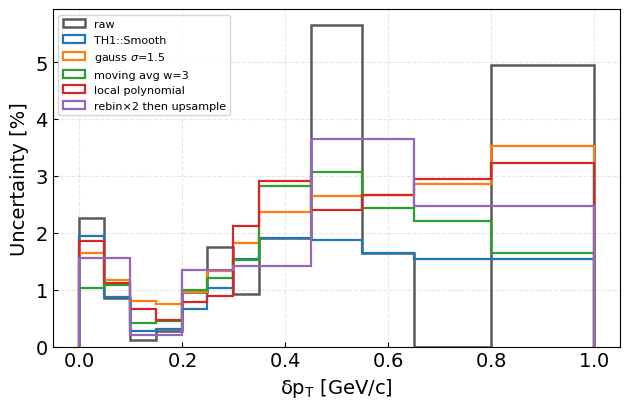

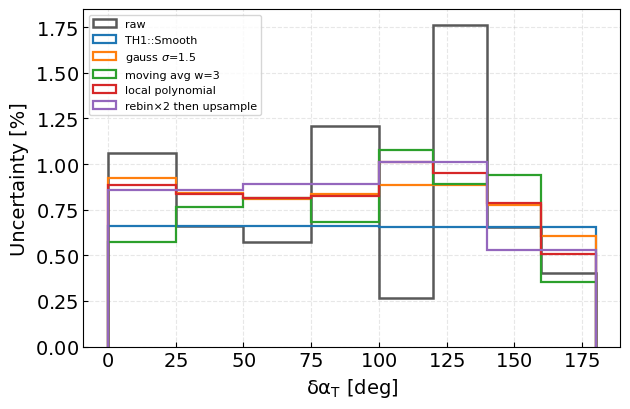

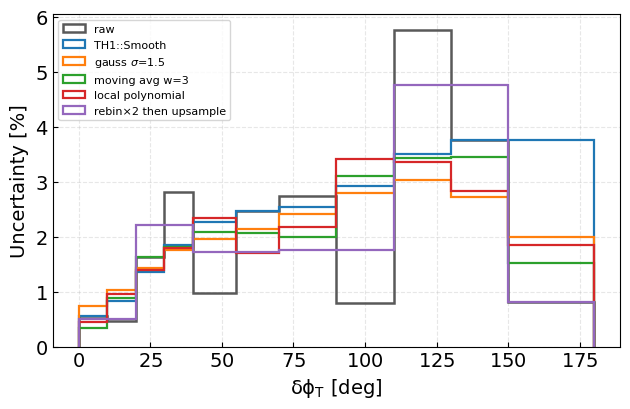

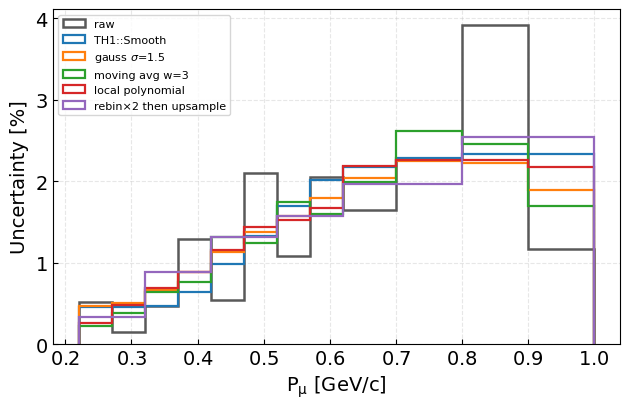

In [11]:
SELECTED_SMOOTH_FIG_DIR = FIG_DIR / "smoothing" / "selected"
SELECTED_SMOOTH_FIG_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_VARS = [
    VariableConfig.tki_del_Tp(),
    VariableConfig.tki_del_alpha(),
    VariableConfig.tki_del_phi(),
    VariableConfig.muon_momentum(),
]

for vc in SELECTED_VARS:
    vsn = vc.var_save_name
    if vsn not in h_cv_f or vsn not in h_dent_f:
        print("skip (no hist)", vsn)
        continue
    n_cv = np.asarray(h_cv_f[vsn], dtype=float)
    n_dent = np.asarray(h_dent_f[vsn], dtype=float)
    raw = 100.0 * frac_from_hists(n_cv, n_dent)
    pack = dict_b.get("detector-DENT", {}).get(vsn)
    if pack is not None:
        raw = frac_unc_pct_from_pack(pack)

    curves = {
        "raw": raw,
        "TH1::Smooth": 100.0 * smooth_th1(raw / 100.0, ntimes=TH1_SMOOTH_NTIMES),
        r"gauss $\sigma$=1.5": 100.0 * smooth_gauss(raw / 100.0, sigma=1.5),
        "moving avg w=3": 100.0 * smooth_moving_avg(raw / 100.0, width=3),
        "local polynomial": 100.0 * smooth_savgol(raw / 100.0),
        "rebin×2 then upsample": 100.0 * rebin_frac_unc_then_upsample(raw / 100.0, factor=2),
    }

    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    styles = [
        ("raw", dict(color="0.35", lw=1.8)),
        ("TH1::Smooth", dict(lw=1.6)),
        (r"gauss $\sigma$=1.5", dict(lw=1.6)),
        ("moving avg w=3", dict(lw=1.6)),
        ("local polynomial", dict(lw=1.6)),
        ("rebin×2 then upsample", dict(lw=1.6)),
    ]
    for lab, st in styles:
        ax.hist(
            vc.bin_centers,
            bins=vc.bins,
            weights=curves[lab],
            histtype="step",
            label=lab,
            **st,
        )
    ax.set_ylabel("Uncertainty [%]")
    ax.set_xlabel(vc.var_labels[0] if vc.var_labels else vsn)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    if SAVE_FIGS:
        fig.savefig(
            SELECTED_SMOOTH_FIG_DIR / f"dent_smooth_selected__{vsn}.png",
            dpi=dpi,
            bbox_inches="tight",
        )
    plt.show()
